## CTD Report, Lake Zug, 27.03.2026

In [1]:
# imports
import ewgreaders as ewg
import xarray as xr
import pandas as pd
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
lake = 'Zug'
date = '2026-03-27'

In [9]:
data_index = ewg.get_data_index(lake, 'ctd')
di_sel = data_index[data_index['date'] == pd.Timestamp(date)]
di_sel

,lake,date,time,profile_loc,xsc,ysc,sensor,serial_id,fname
165,Zug,2026-03-27,10:58,VMPC,680079,218776,sea&sun,2023,K3271557_1
166,Zug,2026-03-27,11:16,P7,680156,218461,sea&sun,2023,K3271557_2
167,Zug,2026-03-27,11:36,P7W,679954,218438,sea&sun,2023,K3271557_3
168,Zug,2026-03-27,11:51,VMPC,680115,218778,sea&sun,2023,K3271557_4
169,Zug,2026-03-27,12:11,P5',679341,219528,sea&sun,2023,K3271557_5
170,Zug,2026-03-27,12:25,P5'',679713,219091,sea&sun,2023,K3271557_6
171,Zug,2026-03-27,12:41,VMPC,680111,218781,sea&sun,2023,K3271557_7
172,Zug,2026-03-27,13:00,P6W,679962,218696,sea&sun,2023,K3271557_8
173,Zug,2026-03-27,13:16,P6E,680291,218809,sea&sun,2023,K3271557_9
174,Zug,2026-03-27,13:27,P7,680150,218456,sea&sun,2023,K3271557_10


In [10]:
data = []
for _, p in di_sel.iterrows():
    ctdreader = ewg.ctd_reader.CTDReader(p.lake, p.date, p.fname)
    ds = ctdreader.load()
    df = ds.to_dataframe().reset_index()
    df[['profile_loc', 'time_local', 'xsc', 'ysc', 'lake_depth']] = ds.attrs['profile_loc'], ds.attrs['time'], ds.attrs['xsc'], ds.attrs['ysc'], ds.attrs['lake_depth']
    data.append(df)

data = pd.concat(data, ignore_index=True).sort_values(by='time_local')

In [12]:
n_locs = data['profile_loc'].nunique()
n_locs

10

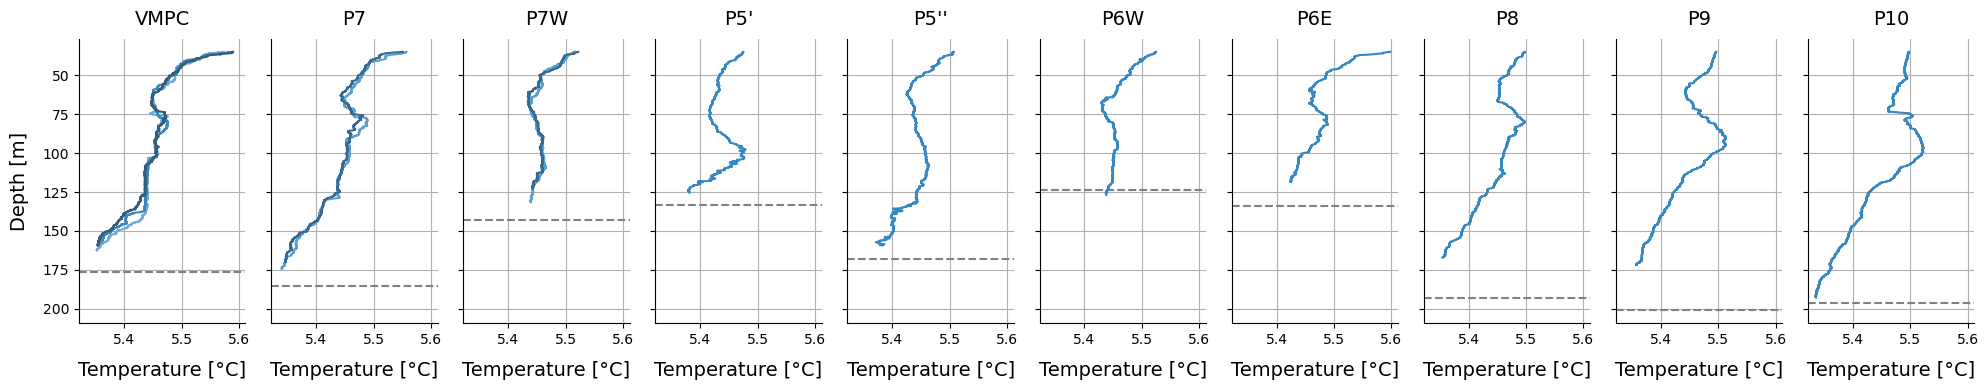

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=n_locs, figsize=(n_locs*2, 4), sharey=True, sharex=True)

for i, (pl, dat) in enumerate(data.query("depth > 35").groupby('profile_loc', sort=False)):
    ax[i].axhline(dat['lake_depth'].mean(), color='gray', linestyle='--')
    sns.lineplot(dat, x='temp', y='depth', orient='y', hue='time_local', palette='Blues_d', ax=ax[i], legend=False)

    ax[i].set_xlabel('Temperature [°C]', fontsize=14, labelpad=10)
    ax[i].set_title(pl, fontsize=14, pad=10)

    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax[0].invert_yaxis()
plt.tight_layout()
plt.show()

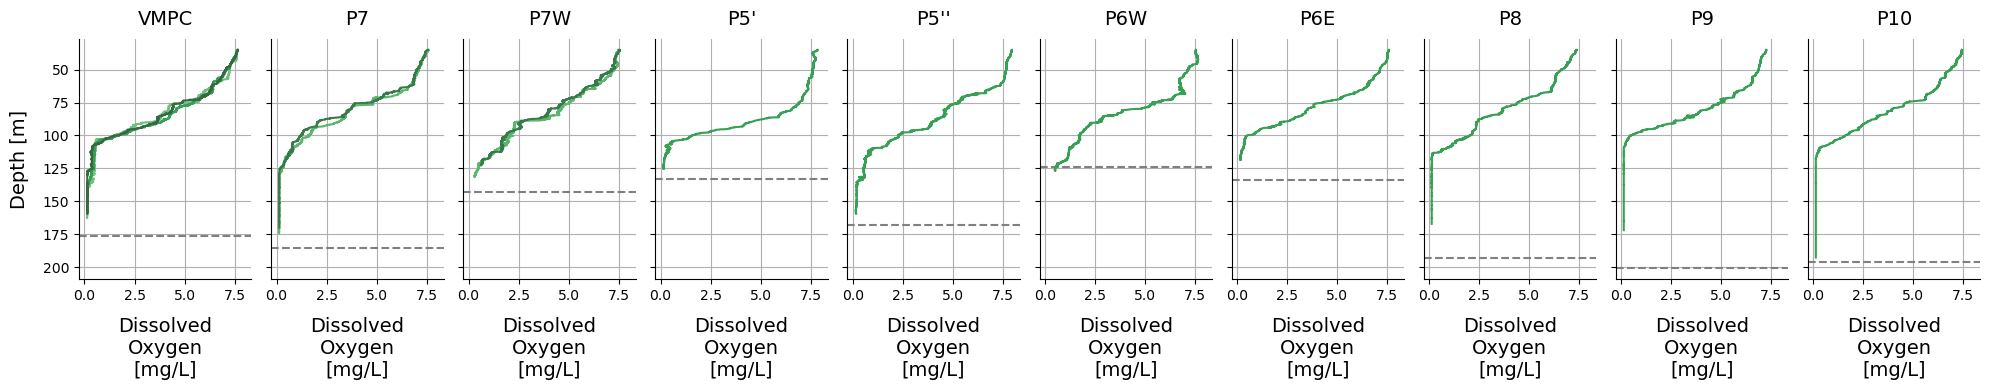

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=n_locs, figsize=(n_locs*2, 4), sharey=True, sharex=True)

for i, (pl, dat) in enumerate(data.query("depth > 35").groupby('profile_loc', sort=False)):
    ax[i].axhline(dat['lake_depth'].mean(), color='gray', linestyle='--')
    sns.lineplot(dat, x='do2_conc', y='depth', orient='y', hue='time_local', palette='Greens_d', ax=ax[i], legend=False)

    ax[i].set_xlabel('Dissolved\nOxygen\n[mg/L]', fontsize=14, labelpad=10)
    ax[i].set_title(pl, fontsize=14, pad=10)

    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax[0].invert_yaxis()
plt.tight_layout()
plt.show()

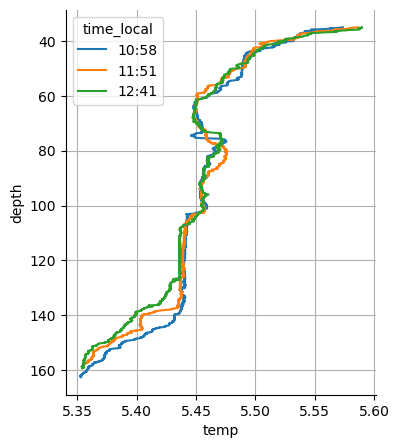

In [27]:
fig, ax = plt.subplots(figsize=(4, 5))

data_sel = data[data['profile_loc'].isin(['VMPC'])].query("depth > 35")

sns.lineplot(data_sel, x='temp', y='depth', orient='y', hue='time_local', ax=ax)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

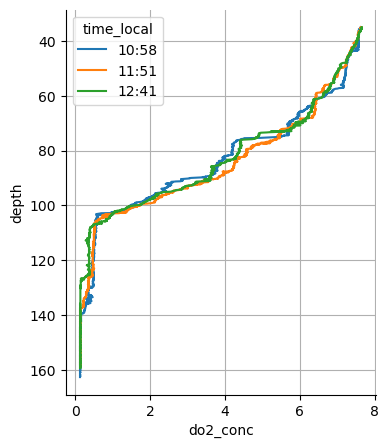

In [28]:
fig, ax = plt.subplots(figsize=(4, 5))

data_sel = data[data['profile_loc'].isin(['VMPC'])].query("depth > 35")

sns.lineplot(data_sel, x='do2_conc', y='depth', orient='y', hue='time_local', ax=ax)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

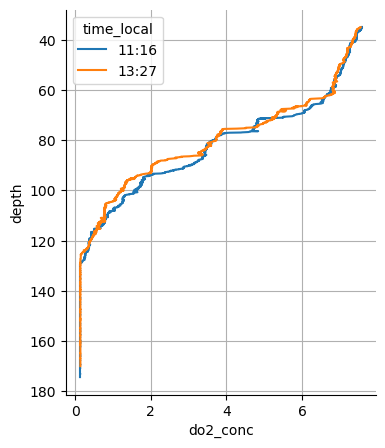

In [32]:
fig, ax = plt.subplots(figsize=(4, 5))

data_sel = data[data['profile_loc'].isin(['P7'])].query("depth > 35")

sns.lineplot(data_sel, x='do2_conc', y='depth', orient='y', hue='time_local', ax=ax)

ax.invert_yaxis()
ax.spines[['right', 'top']].set_visible(False)
ax.grid(True)

plt.show()

In [16]:
data.query("profile_loc == 'P7W'").depth.max()

131.52965868563126

In [146]:
min_do = data['do2_conc'].min()
e = 0.02
err = 0.2

anoxic_data = []
for (t, pl, x, y), dat in data.groupby(['time_local', 'profile_loc', 'xsc', 'ysc']):
    oxic_depth = dat[dat['do2_conc'] > min_do + e].depth.max()
    anoxic_depth = dat[dat['do2_conc'] <= min_do + e].depth.min()
    anoxic_err = dat[dat['do2_conc'] <= min_do + err].depth.min()

    anoxic_data.append({
        'time_local': t,
        'profile_loc': pl,
        'xsc': x,
        'ysc': y,
        'lake_depth': dat['lake_depth'].mean(),
        'oxic_depth': oxic_depth,
        'anoxic_depth': anoxic_depth,
        'anoxic_err': anoxic_err
    })

anoxic_data = pd.DataFrame(anoxic_data).sort_values(by='time_local')

In [147]:
anoxic_data

,time_local,profile_loc,xsc,ysc,lake_depth,oxic_depth,anoxic_depth,anoxic_err
0,10:58,VMPC,680079,218776,177.0,142.540137,140.047203,131.350016
1,11:16,P7,680156,218461,185.0,128.892365,128.939045,124.037846
2,11:36,P7W,679954,218438,145.0,131.529659,NaN,130.085284
3,11:51,VMPC,680115,218778,176.0,137.460900,137.489842,130.592029
4,12:11,P5',679341,219528,133.0,125.176455,121.539846,107.215159
5,12:25,P5'',679713,219091,168.0,159.283751,156.491440,131.490052
6,12:41,VMPC,680111,218781,176.0,127.609496,126.689662,112.013045
7,13:00,P6W,679962,218696,124.0,126.815477,NaN,NaN
8,13:16,P6E,680291,218809,134.0,118.579161,NaN,108.534181
9,13:27,P7,680150,218456,186.0,125.557938,125.493319,122.852311


,time_local,profile_loc,xsc,ysc,label,depth
13,14:48,P10,680791,216262,oxic_depth,116.642266
27,14:48,P10,680791,216262,anoxic_depth,116.713970
55,14:48,P10,680791,216262,lake_depth,196.000000
41,14:48,P10,680791,216262,anoxic_err,109.361040
40,14:28,P9,680415,217440,anoxic_err,102.762742
54,14:28,P9,680415,217440,lake_depth,201.000000
26,14:28,P9,680415,217440,anoxic_depth,108.994331
12,14:28,P9,680415,217440,oxic_depth,108.965588
11,13:56,P8,680224,218119,oxic_depth,115.582000
25,13:56,P8,680224,218119,anoxic_depth,115.621382


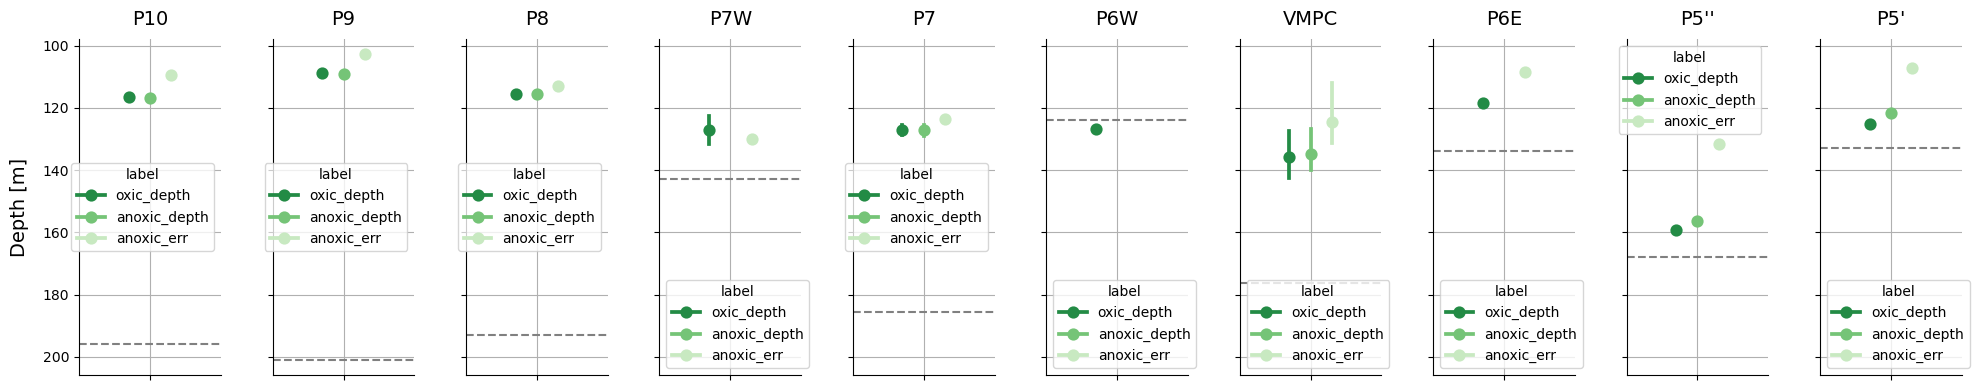

In [159]:
dfm = pd.melt(anoxic_data, id_vars=['time_local', 'profile_loc', 'xsc', 'ysc', 'lake_depth'], value_vars=['oxic_depth', 'anoxic_depth', 'anoxic_err'],
              var_name='label', value_name='depth').sort_values(by='ysc')
dfm

fig, ax = plt.subplots(nrows=1, ncols=n_locs, figsize=(n_locs*2, 4), sharey=True, sharex=True)
order = ['oxic_depth', 'anoxic_depth', 'anoxic_err']

for i, (pl, dat) in enumerate(dfm.groupby('profile_loc', sort=False)):
    ax[i].axhline(dat['lake_depth'].mean(), color='gray', linestyle='--')
    sns.pointplot(dat, y='depth', orient='y', hue='label', hue_order=order, palette='Greens_r', dodge=0.3, ax=ax[i], legend=True)

    ax[i].set_title(pl, fontsize=14, pad=10)

    ax[i].spines[['right', 'top']].set_visible(False)
    ax[i].grid(True)

ax[0].set_ylabel('Depth [m]', fontsize=14, labelpad=10)

ax[0].invert_yaxis()
plt.tight_layout()
plt.show()

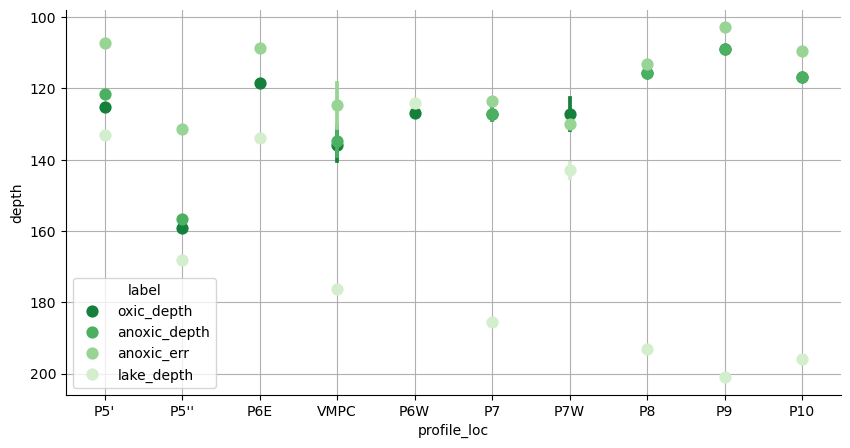

In [158]:
dfm = pd.melt(anoxic_data, id_vars=['time_local', 'profile_loc', 'xsc', 'ysc'], value_vars=['oxic_depth', 'anoxic_depth', 'anoxic_err', 'lake_depth'],
              var_name='label', value_name='depth').sort_values(by='ysc')
dfm

fig, ax = plt.subplots(figsize=(10, 5))
order = ['oxic_depth', 'anoxic_depth', 'anoxic_err', 'lake_depth']

sns.pointplot(dfm, x='profile_loc', y='depth', hue='label', hue_order=order, palette='Greens_r', linestyle='none', dodge=0., errorbar=('se', 1), ax=ax)
#sns.stripplot(dfm, x='profile_loc', y='depth', hue='label', palette='Greens_d', dodge=0.3, ax=ax)

ax.invert_xaxis()
ax.invert_yaxis()
ax.grid(True)
ax.spines[['right', 'top']].set_visible(False)
plt.show()